# Gercon - Exploração de Dados

Notebook de exploração inicial do banco **gercon** — Tese de Doutorado.

Base analisada: `gercon_solicitacoes_executante_porto_alegre_2018_2025.csv` (~918 MB).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Caminhos do projeto
base_path = '/content/drive/MyDrive/01_Doutorado/Tese/banco/gercon'
csv_path = f'{base_path}/gercon_solicitacoes_executante_porto_alegre_2018_2025.csv'

# Colunas de ID/código: categóricas por natureza, mesmo sendo só dígitos.
# Forçadas para string já na leitura para não virarem int64 e não perderem zeros à esquerda.
ID_COLS = [
    'idsolicitacao',
    'idpaciente',
    'cnes_solicitante',
    'cnesexecutante',
]
ID_COLS_DTYPE = {col: str for col in ID_COLS}

# Colunas descartadas da análise (metadados de extração / redundantes)
DROP_COLS = [
    'data_extracao',
    'COD_IBGE_MUNICIPIO_EXECUTANTE_7D',
    'COD_IBGE_MUNICIPIO_EXECUTANTE_6D',
    'UF_EXECUTANTE',
    'ARQUIVO_ORIGEM',
]

## 1. Carregamento dos dados

O arquivo tem cerca de **918 MB**. Antes de carregar tudo em memória, vale conferir separador, encoding e uma amostra das colunas. Ajuste `SEP` e `ENCODING` conforme o resultado da célula de preview abaixo, se necessário.

In [ ]:
SEP = ';'
ENCODING = 'utf-8'

# Preview rápido só com as primeiras linhas, para checar separador/encoding/colunas
preview = pd.read_csv(csv_path, sep=SEP, encoding=ENCODING, nrows=20, dtype=ID_COLS_DTYPE)
preview

,data_extracao,idsolicitacao,situacaosolicitacao,data_solicitacao,corregulador,diasfilaespera,complexidade,especialidade,especialidademae,cid,idpaciente,municipio_residencia,idade,cnes_solicitante,unidadesolicitante,tipounidade,municipiosolicitante,situacaoagenda,datahora_consulta,cnesexecutante,unidadeexecutante,municipio_executante,statusregionalizacao,centralregulacao,centralregulacaoorigem,tipoconsulta,coordenadoriasolicitante,regiaosaudesolicitante,possuiunidadeindicada,COD_IBGE_MUNICIPIO_EXECUTANTE_7D,COD_IBGE_MUNICIPIO_EXECUTANTE_6D,UF_EXECUTANTE,ARQUIVO_ORIGEM
0,2025-01-07 00:00:00.000,747495,REALIZADA,2018-02-20 00:00:00.000,AMARELO,17,MEDIA,CIRURGIA BUCOMAXILOFACIAL CEO,CIRURGIA BUCOMAXILOFACIAL,K011,520120,PORTO ALEGRE,27,2265133,UNIDADE DE SAUDE SESC,CENTRO DE SAUDE/UNIDADE BASICA,PORTO ALEGRE,REALIZADA,2018-03-21 00:00:00.000,7031092,CENTRO DE ESPECIALIDADES ODONTOLOGICAS CEO LENO,PORTO ALEGRE,NaN,REGULACAO AMBULATORIAL,REGULACAO AMBULATORIAL,PRIMEIRA,1ª CRS,REGIÃO DE SAÚDE 10,SIM,4314902,431490,RS,gercon_solicitacoes_2018.csv
1,2025-01-07 00:00:00.000,756290,REALIZADA,2018-02-28 00:00:00.000,AZUL,14,MEDIA,CIRURGIA BUCOMAXILOFACIAL CEO,CIRURGIA BUCOMAXILOFACIAL,K021,524958,PORTO ALEGRE,53,2237911,UNIDADE DE SAUDE SAFIRA NOVA,CENTRO DE SAUDE/UNIDADE BASICA,PORTO ALEGRE,REALIZADA,2018-03-28 00:00:00.000,7031092,CENTRO DE ESPECIALIDADES ODONTOLOGICAS CEO LENO,PORTO ALEGRE,NaN,REGULACAO AMBULATORIAL,REGULACAO AMBULATORIAL,PRIMEIRA,1ª CRS,REGIÃO DE SAÚDE 10,SIM,4314902,431490,RS,gercon_solicitacoes_2018.csv
2,2025-01-07 00:00:00.000,806777,REALIZADA,2018-04-12 00:00:00.000,AZUL,1,MEDIA,CIRURGIA BUCOMAXILOFACIAL CEO,CIRURGIA BUCOMAXILOFACIAL,K011,403356,PORTO ALEGRE,29,2264838,UNIDADE DE SAUDE SAO CARLOS,CENTRO DE SAUDE/UNIDADE BASICA,PORTO ALEGRE,REALIZADA,2018-04-26 00:00:00.000,7031092,CENTRO DE ESPECIALIDADES ODONTOLOGICAS CEO LENO,PORTO ALEGRE,NaN,REGULACAO AMBULATORIAL,REGULACAO AMBULATORIAL,PRIMEIRA,1ª CRS,REGIÃO DE SAÚDE 10,NÃO,4314902,431490,RS,gercon_solicitacoes_2018.csv
3,2025-01-07 00:00:00.000,730573,REALIZADA,2018-02-01 00:00:00.000,LARANJA,5,MEDIA,PERIODONTIA,ODONTO PERIODONTIA,K061,260468,PORTO ALEGRE,46,2264404,CLINICA DA FAMILIA JOSE MAURO CERATTI LOPES,CENTRO DE SAUDE/UNIDADE BASICA,PORTO ALEGRE,REALIZADA,2018-02-20 00:00:00.000,7031092,CENTRO DE ESPECIALIDADES ODONTOLOGICAS CEO LENO,PORTO ALEGRE,NaN,REGULACAO AMBULATORIAL,REGULACAO AMBULATORIAL,PRIMEIRA,1ª CRS,REGIÃO DE SAÚDE 10,NÃO,4314902,431490,RS,gercon_solicitacoes_2018.csv
4,2025-01-07 00:00:00.000,744023,ENCERRADA,2018-02-16 00:00:00.000,NENHUM,0,MEDIA,PERIODONTIA,ODONTO PERIODONTIA,K051,518181,PORTO ALEGRE,63,6130917,UNIDADE DE SAUDE NOSSA SENHORA DE BELEM,CENTRO DE SAUDE/UNIDADE BASICA,PORTO ALEGRE,REALIZADA,2018-02-27 00:00:00.000,7031092,CENTRO DE ESPECIALIDADES ODONTOLOGICAS CEO LENO,PORTO ALEGRE,NaN,REGULACAO AMBULATORIAL,REGULACAO AMBULATORIAL,PRIMEIRA,1ª CRS,REGIÃO DE SAÚDE 10,NÃO,4314902,431490,RS,gercon_solicitacoes_2018.csv
5,2025-01-07 00:00:00.000,742036,REALIZADA,2018-02-15 00:00:00.000,NENHUM,1,MEDIA,PERIODONTIA,ODONTO PERIODONTIA,K053,517086,PORTO ALEGRE,22,2264455,UNIDADE DE SAUDE PONTA GROSSA,CENTRO DE SAUDE/UNIDADE BASICA,PORTO ALEGRE,REALIZADA,2018-02-27 00:00:00.000,7031092,CENTRO DE ESPECIALIDADES ODONTOLOGICAS CEO LENO,PORTO ALEGRE,NaN,REGULACAO AMBULATORIAL,REGULACAO AMBULATORIAL,PRIMEIRA,1ª CRS,REGIÃO DE SAÚDE 10,NÃO,4314902,431490,RS,gercon_solicitacoes_2018.csv
6,2025-01-07 00:00:00.000,741057,ENCERRADA,2018-02-14 00:00:00.000,NENHUM,2,MEDIA,PERIODONTIA,ODONTO PERIODONTIA,K029,516537,PORTO ALEGRE,30,6883354,CLINICA DA FAMILIA SANTA MARTA,CENTRO DE SAUDE/UNIDADE BASICA,PORTO ALEGRE,REALIZADA,2018-02-27 00:00:00.000,7031092,CENTRO DE ESPECIALIDADES ODONTOLOGICAS CEO LENO,PORTO ALEGRE,NaN,REGULACAO AMBULATORIAL,REGULACAO AMBULATORIAL,PRIMEIRA,1ª CRS,REGIÃO DE SAÚDE 10,NÃO,4314902,431490,RS,gercon_solicitacoes_2018.csv
7,2025-01-07 00:00:00.000,787302,REALIZADA,2018-03-27 00:00:00.000,AZUL,0,MEDIA,PERIODONTIA,ODONTO PER

In [ ]:
# Config de carregamento completo
# USE_SAMPLE=True carrega apenas uma amostra (mais rápido para explorar o notebook antes de rodar tudo)
USE_SAMPLE = False
SAMPLE_ROWS = 500_000

if USE_SAMPLE:
    df = pd.read_csv(csv_path, sep=SEP, encoding=ENCODING, nrows=SAMPLE_ROWS, low_memory=False, dtype=ID_COLS_DTYPE)
else:
    df = pd.read_csv(csv_path, sep=SEP, encoding=ENCODING, low_memory=False, dtype=ID_COLS_DTYPE)

df.shape

(2147900, 33)

## 1.1 Remoção de colunas desnecessárias

Metadados de extração e colunas redundantes não entram na análise.

In [ ]:
df = df.drop(columns=DROP_COLS, errors='ignore')
df.shape

(2147900, 28)

## 2. Visão geral

In [ ]:
df.head(5)

,idsolicitacao,situacaosolicitacao,data_solicitacao,corregulador,diasfilaespera,complexidade,especialidade,especialidademae,cid,idpaciente,municipio_residencia,idade,cnes_solicitante,unidadesolicitante,tipounidade,municipiosolicitante,situacaoagenda,datahora_consulta,cnesexecutante,unidadeexecutante,municipio_executante,statusregionalizacao,centralregulacao,centralregulacaoorigem,tipoconsulta,coordenadoriasolicitante,regiaosaudesolicitante,possuiunidadeindicada
0,747495,REALIZADA,2018-02-20 00:00:00.000,AMARELO,17,MEDIA,CIRURGIA BUCOMAXILOFACIAL CEO,CIRURGIA BUCOMAXILOFACIAL,K011,520120,PORTO ALEGRE,27,2265133,UNIDADE DE SAUDE SESC,CENTRO DE SAUDE/UNIDADE BASICA,PORTO ALEGRE,REALIZADA,2018-03-21 00:00:00.000,7031092,CENTRO DE ESPECIALIDADES ODONTOLOGICAS CEO LENO,PORTO ALEGRE,NaN,REGULACAO AMBULATORIAL,REGULACAO AMBULATORIAL,PRIMEIRA,1ª CRS,REGIÃO DE SAÚDE 10,SIM
1,756290,REALIZADA,2018-02-28 00:00:00.000,AZUL,14,MEDIA,CIRURGIA BUCOMAXILOFACIAL CEO,CIRURGIA BUCOMAXILOFACIAL,K021,524958,PORTO ALEGRE,53,2237911,UNIDADE DE SAUDE SAFIRA NOVA,CENTRO DE SAUDE/UNIDADE BASICA,PORTO ALEGRE,REALIZADA,2018-03-28 00:00:00.000,7031092,CENTRO DE ESPECIALIDADES ODONTOLOGICAS CEO LENO,PORTO ALEGRE,NaN,REGULACAO AMBULATORIAL,REGULACAO AMBULATORIAL,PRIMEIRA,1ª CRS,REGIÃO DE SAÚDE 10,SIM
2,806777,REALIZADA,2018-04-12 00:00:00.000,AZUL,1,MEDIA,CIRURGIA BUCOMAXILOFACIAL CEO,CIRURGIA BUCOMAXILOFACIAL,K011,403356,PORTO ALEGRE,29,2264838,UNIDADE DE SAUDE SAO CARLOS,CENTRO DE SAUDE/UNIDADE BASICA,PORTO ALEGRE,REALIZADA,2018-04-26 00:00:00.000,7031092,CENTRO DE ESPECIALIDADES ODONTOLOGICAS CEO LENO,PORTO ALEGRE,NaN,REGULACAO AMBULATORIAL,REGULACAO AMBULATORIAL,PRIMEIRA,1ª CRS,REGIÃO DE SAÚDE 10,NÃO
3,730573,REALIZADA,2018-02-01 00:00:00.000,LARANJA,5,MEDIA,PERIODONTIA,ODONTO PERIODONTIA,K061,260468,PORTO ALEGRE,46,2264404,CLINICA DA FAMILIA JOSE MAURO CERATTI LOPES,CENTRO DE SAUDE/UNIDADE BASICA,PORTO ALEGRE,REALIZADA,2018-02-20 00:00:00.000,7031092,CENTRO DE ESPECIALIDADES ODONTOLOGICAS CEO LENO,PORTO ALEGRE,NaN,REGULACAO AMBULATORIAL,REGULACAO AMBULATORIAL,PRIMEIRA,1ª CRS,REGIÃO DE SAÚDE 10,NÃO
4,744023,ENCERRADA,2018-02-16 00:00:00.000,NENHUM,0,MEDIA,PERIODONTIA,ODONTO PERIODONTIA,K051,518181,PORTO ALEGRE,63,6130917,UNIDADE DE SAUDE NOSSA SENHORA DE BELEM,CENTRO DE SAUDE/UNIDADE BASICA,PORTO ALEGRE,REALIZADA,2018-02-27 00:00:00.000,7031092,CENTRO DE ESPECIALIDADES ODONTOLOGICAS CEO LENO,PORTO ALEGRE,NaN,REGULACAO AMBULATORIAL,REGULACAO AMBULATORIAL,PRIMEIRA,1ª CRS,REGIÃO DE SAÚDE 10,NÃO


In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   idsolicitacao             500000 non-null  object
 1   situacaosolicitacao       500000 non-null  object
 2   data_solicitacao          500000 non-null  object
 3   corregulador              499960 non-null  object
 4   diasfilaespera            500000 non-null  int64 
 5   complexidade              500000 non-null  object
 6   especialidade             500000 non-null  object
 7   especialidademae          500000 non-null  object
 8   cid                       500000 non-null  object
 9   idpaciente                500000 non-null  object
 10  municipio_residencia      500000 non-null  object
 11  idade                     500000 non-null  int64 
 12  cnes_solicitante          500000 non-null  object
 13  unidadesolicitante        500000 non-null  object
 14  tipo

In [ ]:
print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")

Linhas: 2,147,900 | Colunas: 28
Memória: 3,309.0 MB


## 3. Valores ausentes

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'n_ausentes': missing, 'pct_ausentes': missing_pct})
missing_df = missing_df[missing_df['n_ausentes'] > 0]
missing_df

,n_ausentes,pct_ausentes
statusregionalizacao,2142910,99.77
cnesexecutante,544994,25.37
unidadeexecutante,544994,25.37
datahora_consulta,544994,25.37
tipoconsulta,544994,25.37
situacaoagenda,544994,25.37
municipio_executante,544994,25.37
corregulador,8229,0.38


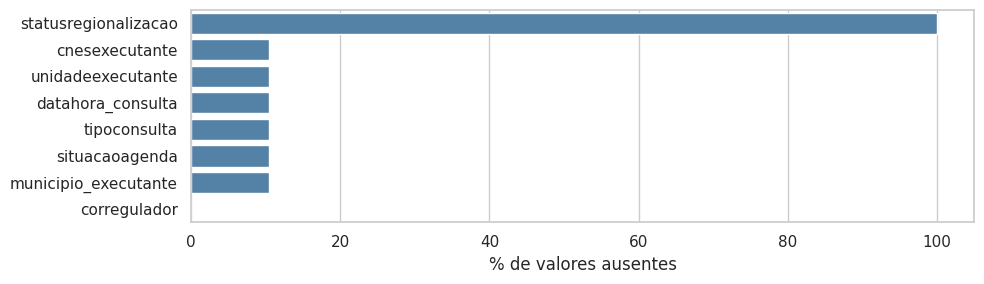

In [ ]:
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(3, len(missing_df) * 0.3)))
    sns.barplot(x=missing_df['pct_ausentes'], y=missing_df.index, ax=ax, color='steelblue')
    ax.set_xlabel('% de valores ausentes')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print('Sem valores ausentes.')

## 4. Duplicatas

In [ ]:
n_dup = df.duplicated().sum()
print(f"Linhas duplicadas: {n_dup:,} ({n_dup / len(df) * 100:.2f}%)")

Linhas duplicadas: 0 (0.00%)


## 5. Identificação automática de tipos de coluna

Tenta converter colunas de texto que parecem datas, e separa numéricas vs. categóricas para as análises seguintes.

In [ ]:
DATE_FORMAT = '%Y-%m-%d %H:%M:%S.%f'

date_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]

for col in df.select_dtypes(include='object').columns:
    if col in ID_COLS or col in date_cols:
        continue
    sample = df[col].dropna().head(200)
    if sample.empty:
        continue
    parsed = pd.to_datetime(sample, format=DATE_FORMAT, errors='coerce')
    if parsed.notna().mean() > 0.9:
        date_cols.append(col)

for col in date_cols:
    if not pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col] = pd.to_datetime(df[col], format=DATE_FORMAT, errors='coerce')

numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ID_COLS]
categorical_cols = [c for c in df.select_dtypes(include='object').columns if c not in date_cols]

print('Colunas de data detectadas:', date_cols)
print('Colunas numéricas:', numeric_cols)
print('Colunas categóricas (inclui IDs/códigos):', categorical_cols)

Colunas de data detectadas: ['data_solicitacao', 'datahora_consulta']
Colunas numéricas: ['diasfilaespera', 'idade']
Colunas categóricas (inclui IDs/códigos): ['idsolicitacao', 'situacaosolicitacao', 'corregulador', 'complexidade', 'especialidade', 'especialidademae', 'cid', 'idpaciente', 'municipio_residencia', 'cnes_solicitante', 'unidadesolicitante', 'tipounidade', 'municipiosolicitante', 'situacaoagenda', 'cnesexecutante', 'unidadeexecutante', 'municipio_executante', 'statusregionalizacao', 'centralregulacao', 'centralregulacaoorigem', 'tipoconsulta', 'coordenadoriasolicitante', 'regiaosaudesolicitante', 'possuiunidadeindicada']


## 6. Estatísticas descritivas — variáveis numéricas

In [ ]:
df[numeric_cols].describe().T if numeric_cols else print('Nenhuma coluna numérica identificada.')

,count,mean,std,min,25%,50%,75%,max
diasfilaespera,2147900.0,261.194876,462.746521,0.0,5.0,46.0,275.0,2499.0
idade,2147900.0,49.711706,22.983192,0.0,33.0,54.0,68.0,125.0


## 7. Distribuição das variáveis numéricas

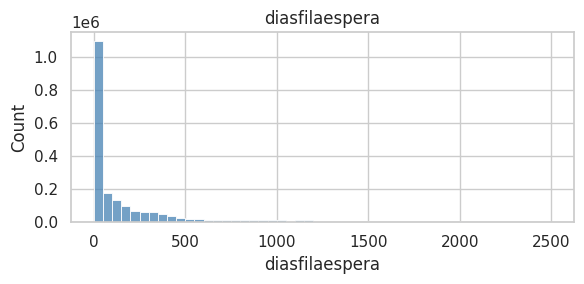

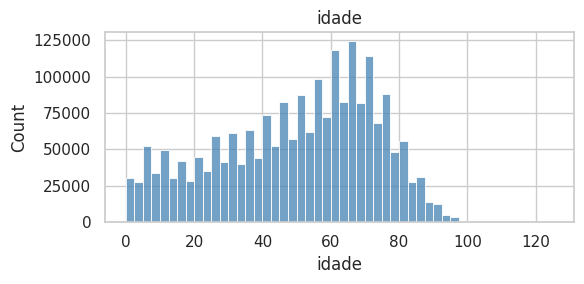

In [ ]:
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.histplot(df[col].dropna(), bins=50, ax=ax, color='steelblue')
    ax.set_title(col)
    plt.tight_layout()
    plt.show()

## 8. Variáveis categóricas

Top 20 categorias mais frequentes por coluna (ignora colunas com cardinalidade muito alta, tipo IDs).

idsolicitacao: 2147900 valores únicos
situacaosolicitacao: 16 valores únicos


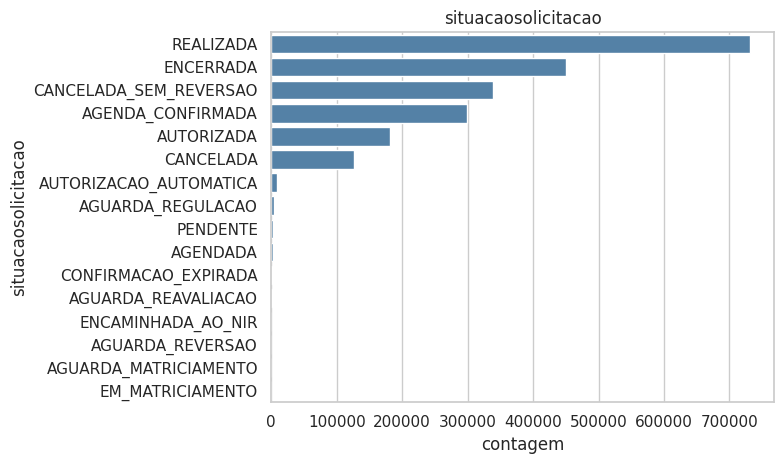

corregulador: 6 valores únicos


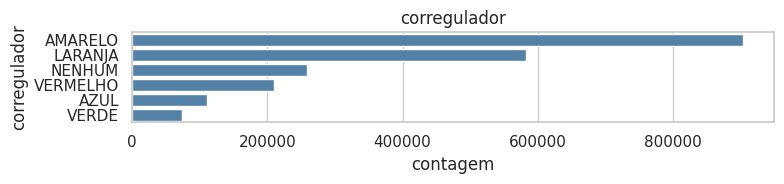

complexidade: 2 valores únicos


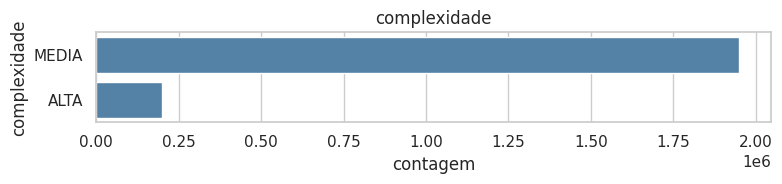

especialidade: 350 valores únicos
especialidademae: 78 valores únicos
cid: 9355 valores únicos
idpaciente: 706089 valores únicos
municipio_residencia: 980 valores únicos
cnes_solicitante: 301 valores únicos
unidadesolicitante: 309 valores únicos
tipounidade: 14 valores únicos


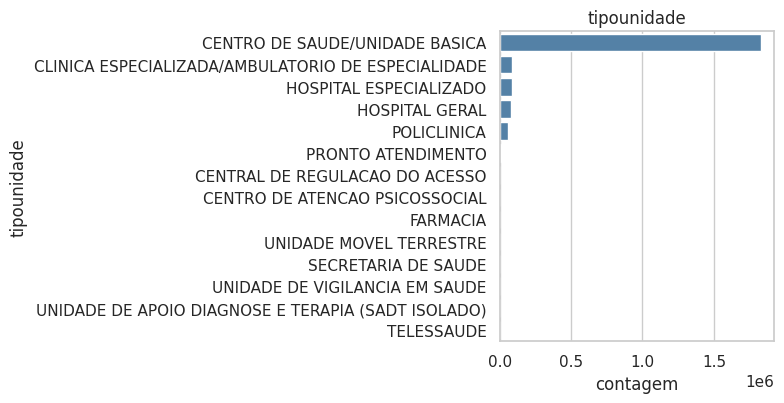

situacaoagenda: 5 valores únicos


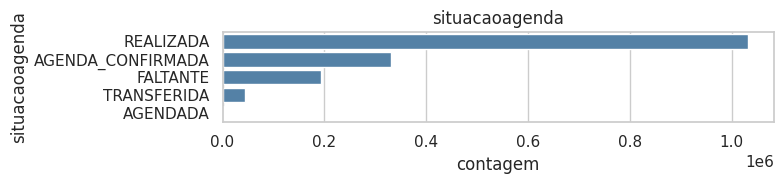

cnesexecutante: 298 valores únicos
unidadeexecutante: 301 valores únicos
municipio_executante: 72 valores únicos
statusregionalizacao: 3 valores únicos


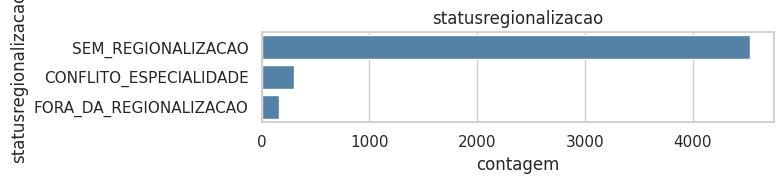

centralregulacao: 23 valores únicos


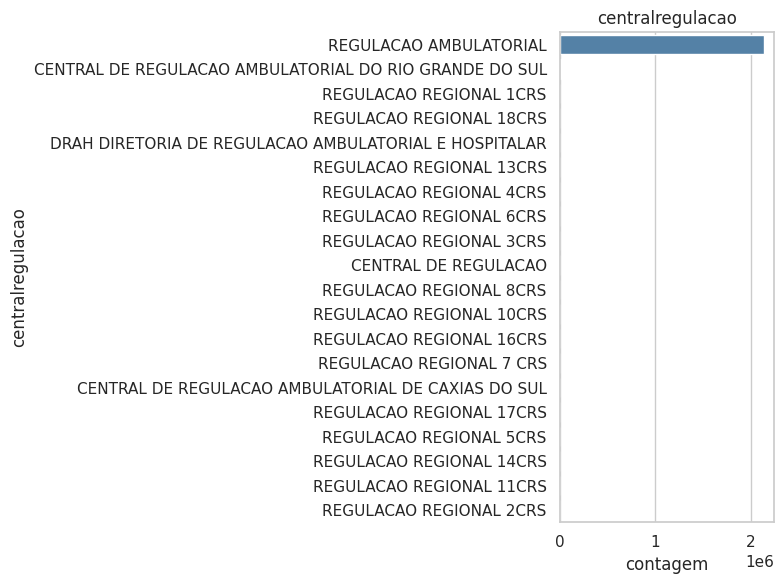

centralregulacaoorigem: 23 valores únicos


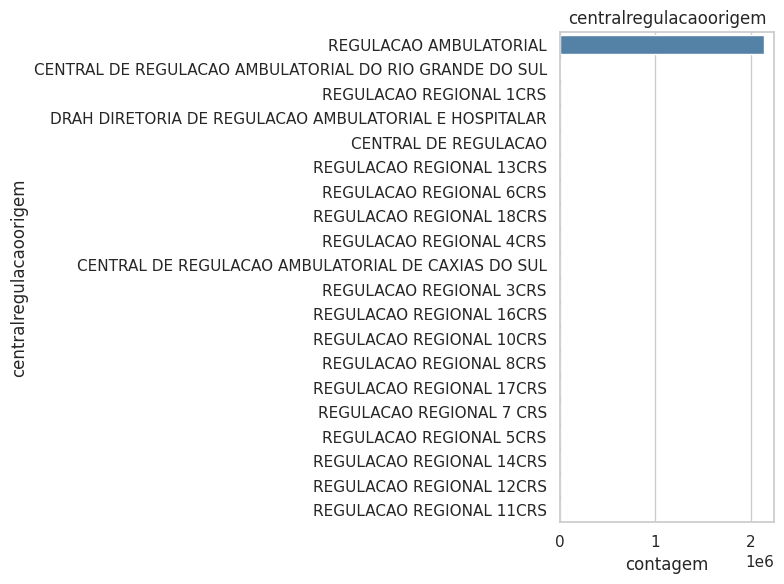

possuiunidadeindicada: 2 valores únicos


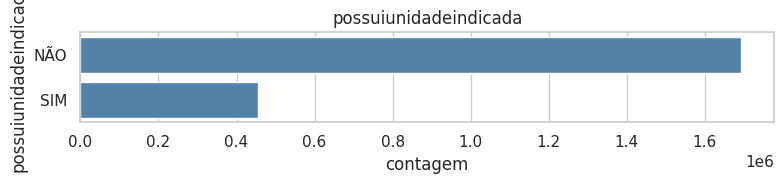

cid_ajustada: 1798 valores únicos


In [ ]:
MAX_CARDINALITY = 50

for col in categorical_cols:
    n_unique = df[col].nunique(dropna=True)
    print(f"{col}: {n_unique} valores únicos")
    if n_unique == 0 or n_unique > MAX_CARDINALITY:
        continue
    top = df[col].value_counts(dropna=True).head(20)
    fig, ax = plt.subplots(figsize=(8, max(2, len(top) * 0.3)))
    sns.barplot(x=top.values, y=top.index, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('contagem')
    plt.tight_layout()
    plt.show()

## 8.1 Remoção de colunas adicionais e ajuste do CID

Remove `regiaosaudesolicitante`, `coordenadoriasolicitante`, `tipoconsulta` e `municipiosolicitante`, e cria `cid_ajustada` com os 3 primeiros caracteres de `cid` (categoria do CID, sem subcategoria).

In [ ]:
DROP_COLS_2 = [
    'regiaosaudesolicitante',
    'coordenadoriasolicitante',
    'tipoconsulta',
    'municipiosolicitante',
]
df = df.drop(columns=DROP_COLS_2, errors='ignore')

# cid_ajustada: categoria do CID (3 primeiros caracteres), sem a subcategoria
df['cid_ajustada'] = df['cid'].astype(str).str[:3]

categorical_cols = [c for c in categorical_cols if c not in DROP_COLS_2] + ['cid_ajustada']

df.shape

(2147900, 25)

## 8.2 Análise bivariada: origem/central de regulação e regionalização x complexidade

Cruzamento de `centralregulacaoorigem`, `centralregulacao` e `statusregionalizacao` com `complexidade`: tabela de contingência (contagem e % por linha), teste qui-quadrado de associação e gráfico de barras empilhadas.

=== centralregulacaoorigem x complexidade ===
n = 2,147,900 (de 2,147,900 linhas; 0 descartadas por valor ausente)


complexidade,ALTA,MEDIA
centralregulacaoorigem,,
CENTRAL DE REGULACAO,83,27
CENTRAL DE REGULACAO AMBULATORIAL DE CAXIAS DO SUL,38,20
CENTRAL DE REGULACAO AMBULATORIAL DO RIO GRANDE DO SUL,7392,4322
DRAH DIRETORIA DE REGULACAO AMBULATORIAL E HOSPITALAR,98,66
REGULACAO AMBULATORIAL,191002,1943181
REGULACAO REGIONAL 10CRS,15,17
REGULACAO REGIONAL 11CRS,4,1
REGULACAO REGIONAL 12CRS,3,3
REGULACAO REGIONAL 13CRS,67,37


complexidade,ALTA,MEDIA
centralregulacaoorigem,,
CENTRAL DE REGULACAO,75.5,24.5
CENTRAL DE REGULACAO AMBULATORIAL DE CAXIAS DO SUL,65.5,34.5
CENTRAL DE REGULACAO AMBULATORIAL DO RIO GRANDE DO SUL,63.1,36.9
DRAH DIRETORIA DE REGULACAO AMBULATORIAL E HOSPITALAR,59.8,40.2
REGULACAO AMBULATORIAL,8.9,91.1
REGULACAO REGIONAL 10CRS,46.9,53.1
REGULACAO REGIONAL 11CRS,80.0,20.0
REGULACAO REGIONAL 12CRS,50.0,50.0
REGULACAO REGIONAL 13CRS,64.4,35.6


Qui-quadrado: 44989.29 | p-valor: 0 | gl: 22


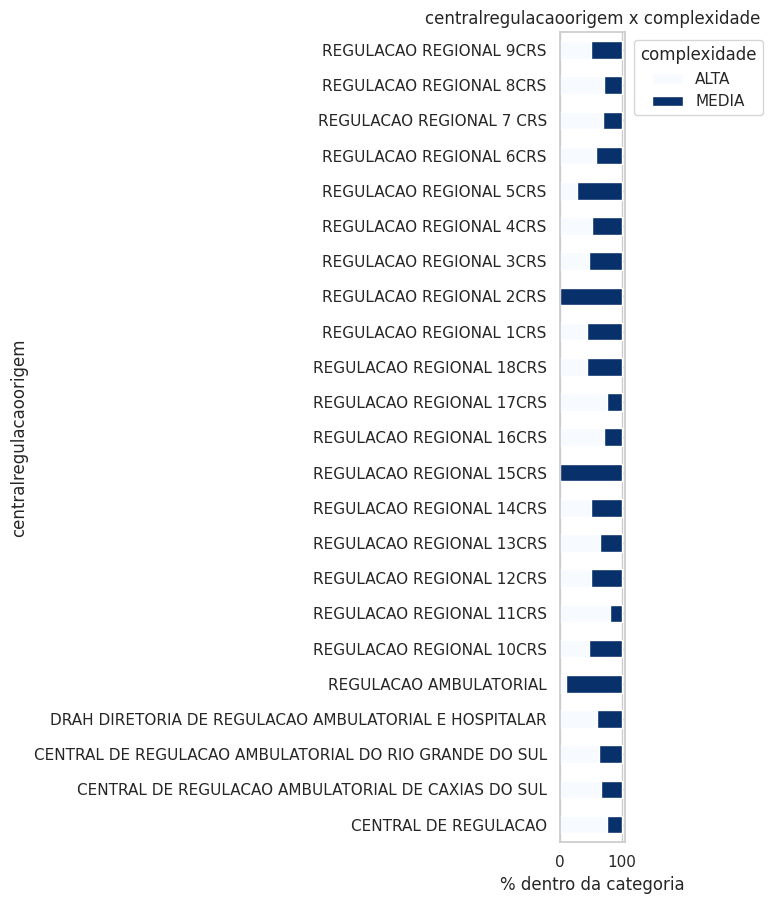


=== centralregulacao x complexidade ===
n = 2,147,900 (de 2,147,900 linhas; 0 descartadas por valor ausente)


complexidade,ALTA,MEDIA
centralregulacao,,
CENTRAL DE REGULACAO,31,16
CENTRAL DE REGULACAO AMBULATORIAL DE CAXIAS DO SUL,17,6
CENTRAL DE REGULACAO AMBULATORIAL DO RIO GRANDE DO SUL,7483,4235
DRAH DIRETORIA DE REGULACAO AMBULATORIAL E HOSPITALAR,58,50
REGULACAO AMBULATORIAL,191266,1943543
REGULACAO REGIONAL 10CRS,13,21
REGULACAO REGIONAL 11CRS,4,5
REGULACAO REGIONAL 12CRS,3,5
REGULACAO REGIONAL 13CRS,61,32


complexidade,ALTA,MEDIA
centralregulacao,,
CENTRAL DE REGULACAO,66.0,34.0
CENTRAL DE REGULACAO AMBULATORIAL DE CAXIAS DO SUL,73.9,26.1
CENTRAL DE REGULACAO AMBULATORIAL DO RIO GRANDE DO SUL,63.9,36.1
DRAH DIRETORIA DE REGULACAO AMBULATORIAL E HOSPITALAR,53.7,46.3
REGULACAO AMBULATORIAL,9.0,91.0
REGULACAO REGIONAL 10CRS,38.2,61.8
REGULACAO REGIONAL 11CRS,44.4,55.6
REGULACAO REGIONAL 12CRS,37.5,62.5
REGULACAO REGIONAL 13CRS,65.6,34.4


Qui-quadrado: 44441.11 | p-valor: 0 | gl: 22


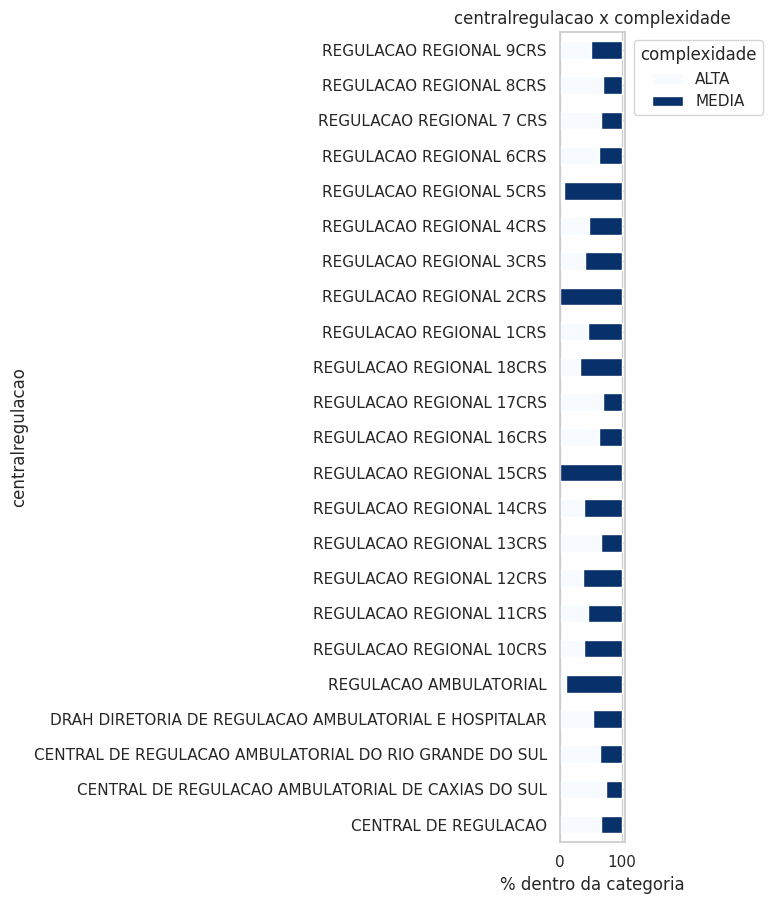


=== statusregionalizacao x complexidade ===
n = 4,990 (de 2,147,900 linhas; 2,142,910 descartadas por valor ausente)


complexidade,ALTA,MEDIA
statusregionalizacao,,
CONFLITO_ESPECIALIDADE,117,184
FORA_DA_REGIONALIZACAO,121,43
SEM_REGIONALIZACAO,2660,1865


complexidade,ALTA,MEDIA
statusregionalizacao,,
CONFLITO_ESPECIALIDADE,38.9,61.1
FORA_DA_REGIONALIZACAO,73.8,26.2
SEM_REGIONALIZACAO,58.8,41.2


Qui-quadrado: 63.15 | p-valor: 1.942e-14 | gl: 2


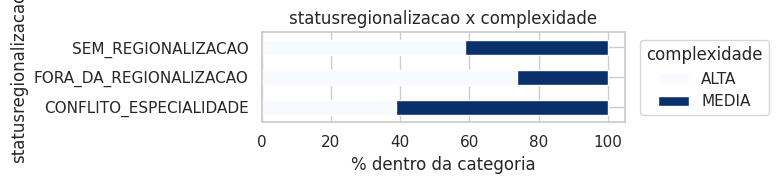

In [ ]:
from scipy.stats import chi2_contingency

BIVAR_COLS = ['centralregulacaoorigem', 'centralregulacao', 'statusregionalizacao']

for col in BIVAR_COLS:
    if col not in df.columns:
        print(f'{col} não encontrada no dataframe.\n')
        continue

    sub = df[[col, 'complexidade']].dropna()
    print(f'=== {col} x complexidade ===')
    print(f'n = {len(sub):,} (de {len(df):,} linhas; {len(df) - len(sub):,} descartadas por valor ausente)')

    if sub.empty:
        print('Sem dados não-nulos para cruzar.\n')
        continue

    ct = pd.crosstab(sub[col], sub['complexidade'])
    ct_pct = pd.crosstab(sub[col], sub['complexidade'], normalize='index') * 100

    display(ct)
    display(ct_pct.round(1))

    if ct.shape[0] > 1 and ct.shape[1] > 1:
        chi2, p, dof, _ = chi2_contingency(ct)
        print(f'Qui-quadrado: {chi2:.2f} | p-valor: {p:.4g} | gl: {dof}')
    else:
        print('Variação insuficiente para teste qui-quadrado.')

    fig, ax = plt.subplots(figsize=(8, max(2, len(ct) * 0.4)))
    ct_pct.plot(kind='barh', stacked=True, ax=ax, colormap='Blues')
    ax.set_xlabel('% dentro da categoria')
    ax.set_title(f'{col} x complexidade')
    ax.legend(title='complexidade', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    print()

## 9. Análise temporal (2018-2025)

Usa a primeira coluna de data detectada automaticamente. Troque `DATE_COL` manualmente se quiser usar outra.

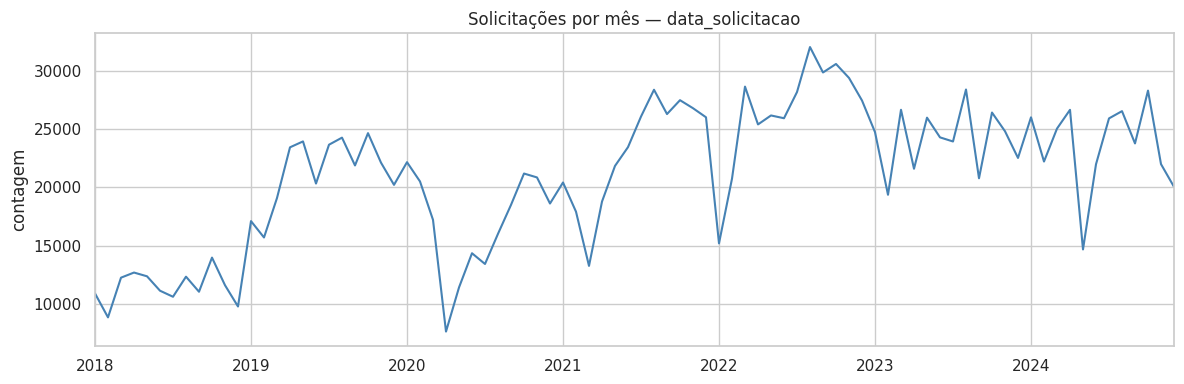

In [ ]:
DATE_COL = date_cols[0] if date_cols else None

if DATE_COL:
    ts = df.set_index(DATE_COL).resample('MS').size()
    fig, ax = plt.subplots(figsize=(12, 4))
    ts.plot(ax=ax, color='steelblue')
    ax.set_title(f'Solicitações por mês — {DATE_COL}')
    ax.set_xlabel('')
    ax.set_ylabel('contagem')
    plt.tight_layout()
    plt.show()
else:
    print('Nenhuma coluna de data foi detectada automaticamente. Ajuste DATE_COL manualmente.')

## 10. Correlação entre variáveis numéricas

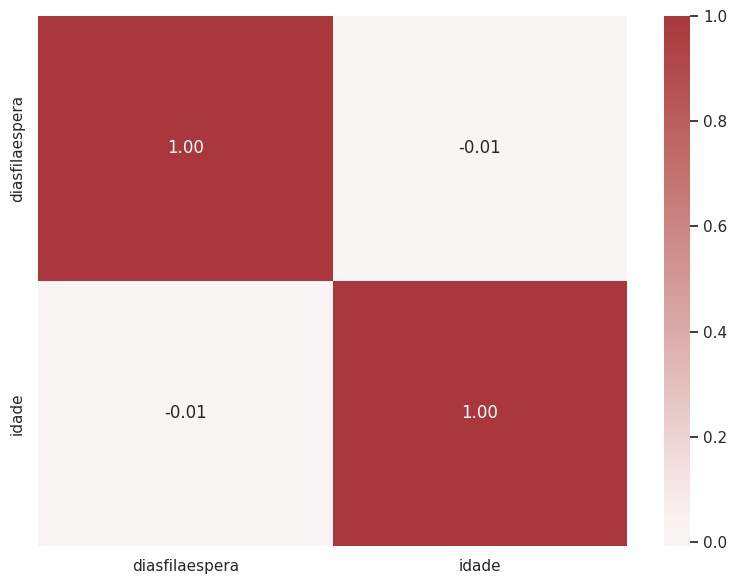

In [ ]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print('Colunas numéricas insuficientes para matriz de correlação.')